1. Ingestion & Profiling

#Ingestion: Load the data

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import missingno as msno

df_raw = pd.read_csv('ops_sensor_log_dirty.csv')

#Profiling: Check data health

In [14]:
print("--- INFO ---")
df_raw.info() # Shows column names, non-null counts, and data types

--- INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5015 entries, 0 to 5014
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   timestamp      5015 non-null   object 
 1   Zone           4984 non-null   object 
 2   Shift          4962 non-null   object 
 3   Pressure_PSI   4975 non-null   float64
 4   Temperature_C  4975 non-null   float64
 5   Flow_Rate_LPM  4966 non-null   float64
dtypes: float64(3), object(3)
memory usage: 235.2+ KB


In [16]:
print("\n--- DESCRIBE ---")
print(df_raw.describe()) # Shows summary statistics (mean, min, max) to spot wild outliers


--- DESCRIBE ---
       Pressure_PSI  Temperature_C  Flow_Rate_LPM
count   4975.000000    4975.000000    4966.000000
mean     255.254281      68.982323     999.275681
std      845.810206      78.829078     231.769525
min      -50.000000    -273.150000     600.007437
25%      160.753008      55.023155     797.417014
50%      200.294439      64.808608     996.286415
75%      240.099173      74.527006    1201.361276
max    15000.000000    1500.000000    1399.755865


#Optional: Visualize missing data

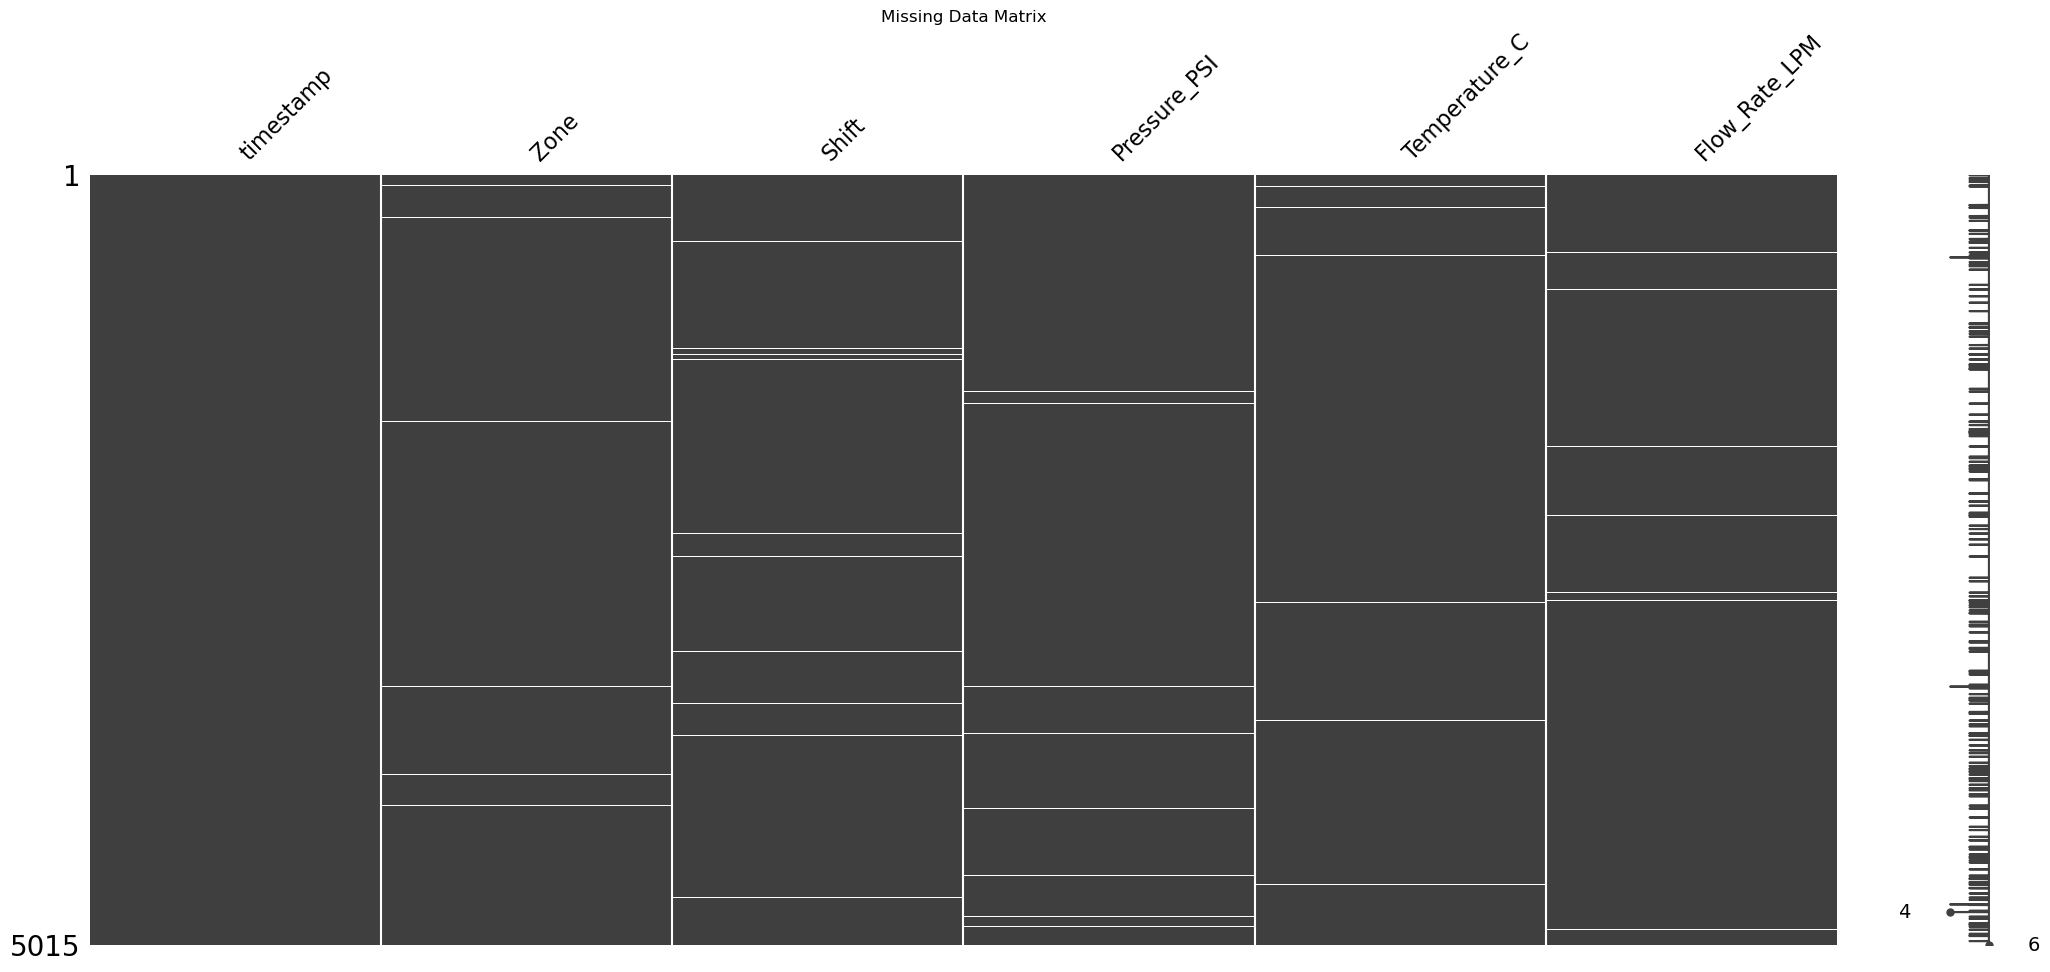

In [17]:
msno.matrix(df_raw)
plt.title("Missing Data Matrix")
plt.show()

## Data Health Report

Based on the initial data profiling using `.info()`, `.describe()`, and `missingno`, several data quality issues were identified that must be addressed in the cleaning pipeline:

*   **Issue 1: Missing Values**
    The dataset contains 5015 total entries, but several columns have missing data. For example, the `Shift` column only has 4962 non-null values (missing 53 entries), and `Pressure_PSI` is missing 40 entries. These gaps will need to be handled to ensure accurate time-series analysis.
*   **Issue 2: Incorrect Data Types** 
    The `timestamp` column is currently loaded as an `object` (string) instead of a proper `datetime` format. This prevents us from doing time-based indexing and resampling.
*   **Issue 3: Extreme Outliers (Sensor Errors)**
    The summary statistics reveal physically impossible sensor readings. The `Pressure_PSI` column has an extreme maximum of 15,000 PSI and an impossible minimum of -50 PSI. Similarly, `Temperature_C` recorded a minimum of -273.15°C (absolute zero). These outliers must be filtered out as they will heavily skew our rolling averages.

2. Cleaning Pipeline

In [47]:
# # # def clean_ops_data(df):
# # #     # Create a copy so we don't alter the original raw dataframe
# # #     clean_df = df.copy()
    
# # #     # 1. Convert timestamps to datetime objects
# # #     # FIX: Changed 'Timestamp' to lowercase 'timestamp'
# # #     clean_df['timestamp'] = pd.to_datetime(clean_df['timestamp'], errors='coerce')
    
# # #     # Drop rows where the timestamp was completely broken
# # #     clean_df = clean_df.dropna(subset=['timestamp'])
    
# # #     # 2. Handle missing values (Justification: Forward fill is best for continuous sensor data)
# # #     # FIX: Changed 'Pressure' to 'Pressure_PSI'
# # #     clean_df['Pressure_PSI'] = clean_df['Pressure_PSI'].ffill()
    
# # #     # 3. Remove exact duplicates
# # #     clean_df = clean_df.drop_duplicates()
    
# # #     # 4. Standardize categorical columns (e.g., stripping spaces, making uppercase)
# # #     if 'Zone' in clean_df.columns:
# # #         clean_df['Zone'] = clean_df['Zone'].astype(str).str.strip().str.upper()
        
# # #     # 5. Filter out physically impossible sensor readings (Outliers)
# # #     # FIX: Changed 'Pressure' to 'Pressure_PSI'
# # #     clean_df = clean_df[(clean_df['Pressure_PSI'] > 0) & (clean_df['Pressure_PSI'] < 1000)]
    
# # #     return clean_df

# # # # Apply the function to your raw data
# # # df_cleaned = clean_ops_data(df_raw)
# # def clean_ops_data(df):
# #     clean_df = df.copy()
    
# #     # Added dayfirst=True
# #     clean_df['timestamp'] = pd.to_datetime(clean_df['timestamp'], errors='coerce', dayfirst=True)
    
# #     clean_df = clean_df.dropna(subset=['timestamp'])
# #     clean_df['Pressure_PSI'] = clean_df['Pressure_PSI'].ffill()
# #     clean_df = clean_df.drop_duplicates()
    
# #     if 'Zone' in clean_df.columns:
# #         clean_df['Zone'] = clean_df['Zone'].astype(str).str.strip().str.upper()
        
# #     clean_df = clean_df[(clean_df['Pressure_PSI'] > 0) & (clean_df['Pressure_PSI'] < 1000)]
    
# #     return clean_df

# # # Apply the fixed function
# # df_cleaned = clean_ops_data(df_raw)
# def clean_ops_data(df):
#     clean_df = df.copy()
#     clean_df['timestamp'] = pd.to_datetime(clean_df['timestamp'], errors='coerce', dayfirst=True)
#     clean_df = clean_df.dropna(subset=['timestamp'])
    
#     # NEW FIX: Filter out any dates that are way in the future
#     # This ensures we only keep our target week in January 2026
#     clean_df = clean_df[(clean_df['timestamp'] >= '2026-01-01') & (clean_df['timestamp'] < '2026-02-01')]
    
#     clean_df['Pressure_PSI'] = clean_df['Pressure_PSI'].ffill()
#     clean_df = clean_df.drop_duplicates()
    
#     if 'Zone' in clean_df.columns:
#         clean_df['Zone'] = clean_df['Zone'].astype(str).str.strip().str.upper()
        
#     clean_df = clean_df[(clean_df['Pressure_PSI'] > 0) & (clean_df['Pressure_PSI'] < 1000)]
    
#     return clean_df

# # Apply the function
# df_cleaned = clean_ops_data(df_raw)
def clean_ops_data(df):
    clean_df = df.copy()
    
    # Standard datetime conversion
    clean_df['timestamp'] = pd.to_datetime(clean_df['timestamp'], errors='coerce')
    clean_df = clean_df.dropna(subset=['timestamp'])
    
    # THE ULTIMATE FIX: Sort the data chronologically!
    clean_df = clean_df.sort_values('timestamp')
    
    # Forward fill missing values
    clean_df['Pressure_PSI'] = clean_df['Pressure_PSI'].ffill()
    
    # Remove duplicates
    clean_df = clean_df.drop_duplicates()
    
    # Standardize Zone
    if 'Zone' in clean_df.columns:
        clean_df['Zone'] = clean_df['Zone'].astype(str).str.strip().str.upper()
        
    # Filter physical outliers
    clean_df = clean_df[(clean_df['Pressure_PSI'] > 0) & (clean_df['Pressure_PSI'] < 1000)]
    
    return clean_df

# Apply the function
df_cleaned = clean_ops_data(df_raw)

1. Actual data (first 5 rows):

In [48]:
df_cleaned.head()

,timestamp,Zone,Shift,Pressure_PSI,Temperature_C,Flow_Rate_LPM
4051,2026-01-07 09:10:00,ZONE_CENTRAL,Morning,139.019377,75.264388,1022.669370
1910,2026-06-25 00:00:00,ZONE_WEST,Afternoon,208.772127,60.187183,1389.618466
3281,2026-06-25 00:02:00,ZONE_CENTRAL,Night,174.563228,80.516074,838.682905
3576,2026-06-25 00:04:00,ZONE_EAST,Afternoon,273.898380,61.167795,1092.215328
4263,2026-06-25 00:06:00,ZONE_CENTRAL,Afternoon,207.585025,69.989314,791.606195


2. Verify the Data Types and Missing Values are fixed:

In [50]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4949 entries, 4051 to 672
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   timestamp      4949 non-null   datetime64[ns]
 1   Zone           4949 non-null   object        
 2   Shift          4898 non-null   object        
 3   Pressure_PSI   4949 non-null   float64       
 4   Temperature_C  4909 non-null   float64       
 5   Flow_Rate_LPM  4901 non-null   float64       
dtypes: datetime64[ns](1), float64(3), object(2)
memory usage: 270.6+ KB


3. Verify the Outliers are gone:

In [51]:
df_cleaned.describe()

,timestamp,Pressure_PSI,Temperature_C,Flow_Rate_LPM
count,4949,4949.000000,4909.000000,4901.000000
mean,2026-06-28 10:16:32.273186304,200.124433,69.022183,999.322811
min,2026-01-07 09:10:00,120.029631,-273.150000,600.007437
25%,2026-06-26 17:20:00,161.083122,55.013383,797.090522
50%,2026-06-28 11:00:00,200.363978,64.791074,997.037673
75%,2026-06-30 04:48:00,239.745015,74.519455,1201.217278
max,2026-07-01 22:38:00,279.958604,1500.000000,1399.755865
std,NaN,46.118999,79.346753,231.823195


4. See how many rows you dropped:

In [52]:
print(f"Original rows: {len(df_raw)}")
print(f"Cleaned rows: {len(df_cleaned)}")
print(f"Rows removed: {len(df_raw) - len(df_cleaned)}")

Original rows: 5015
Cleaned rows: 4949
Rows removed: 66


3. Time-Series Analysis

In [53]:
# # # # 1. Set the timestamp column as the index of the dataframe
# # # df_time = df_cleaned.set_index('timestamp')

# # # # 2. Resample to an hourly ('H') frequency, taking the mean of Pressure_PSI for that hour
# # # hourly_data = df_time['Pressure_PSI'].resample('H').mean()

# # # # 3. Calculate a 24-hour rolling average on the hourly data
# # # rolling_24h = hourly_data.rolling(window=24).mean()

# # # # Let's peek at the rolling average data to make sure it worked
# # # print(rolling_24h.head(30)) # The first 23 rows will say 'NaN' because it needs 24 hours to calculate the first average!
# # df_time = df_cleaned.set_index('timestamp')
# # hourly_data = df_time['Pressure_PSI'].resample('H').mean()
# # rolling_24h = hourly_data.rolling(window=24).mean()
# df_time = df_cleaned.set_index('timestamp')
# hourly_data = df_time['Pressure_PSI'].resample('H').mean()
# rolling_24h = hourly_data.rolling(window=24).mean()
# Because the data is now sorted, the rolling average will work perfectly
df_time = df_cleaned.set_index('timestamp')
hourly_data = df_time['Pressure_PSI'].resample('H').mean()
rolling_24h = hourly_data.rolling(window=24).mean()

C:\Users\kelvi\AppData\Local\Temp\ipykernel_24448\4070126693.py:20: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hourly_data = df_time['Pressure_PSI'].resample('H').mean()


4. Aggregation

In [54]:
# Group by Shift and Zone, then calculate statistics for Pressure_PSI
summary_table = df_cleaned.groupby(['Shift', 'Zone'])['Pressure_PSI'].agg(['mean', 'max', 'min']).reset_index()

# The .reset_index() command just makes the output look like a clean, flat table again.
print("--- SHIFT & ZONE SUMMARY TABLE ---")
print(summary_table)

--- SHIFT & ZONE SUMMARY TABLE ---
        Shift          Zone        mean         max         min
0   Afternoon           NAN  205.531391  268.906001  123.005492
1   Afternoon    NORTH ZONE  224.601162  277.069521  172.132803
2   Afternoon    SOUTH ZONE  219.438805  250.847309  188.030301
3   Afternoon    ZONE NORTH  205.806646  275.115651  137.049517
4   Afternoon    ZONE SOUTH  157.908147  157.908147  157.908147
5   Afternoon    ZONE-NORTH  194.568814  235.623552  152.333306
6   Afternoon  ZONE_CENTRAL  200.957807  279.941700  120.216884
7   Afternoon     ZONE_EAST  203.715181  278.852932  120.863767
8   Afternoon    ZONE_NORTH  202.866339  279.854523  120.029631
9   Afternoon    ZONE_SOUTH  203.218734  279.724389  120.218877
10  Afternoon     ZONE_WEST  197.156034  279.607715  120.252707
11  Afternoon       Z_NORTH  233.718874  245.592898  221.844850
12  Afternoon       Z_SOUTH  230.818123  275.888794  185.747451
13    Morning           NAN  216.600462  269.332707  127.002536
14   

5. Visualization

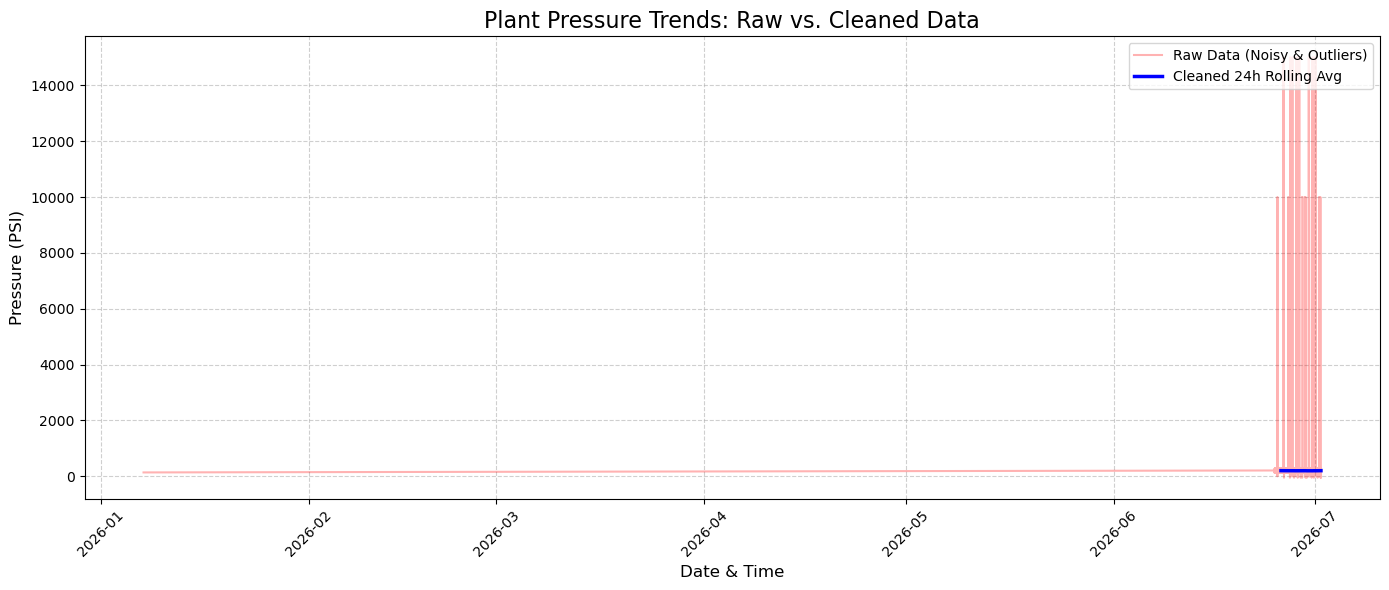

In [55]:
# # # import matplotlib.pyplot as plt

# # # # Set the size of the chart
# # # plt.figure(figsize=(14, 6))

# # # # Prepare the raw data strictly for plotting (converting the string timestamps to datetime)
# # # df_raw_plot = df_raw.copy()
# # # df_raw_plot['timestamp'] = pd.to_datetime(df_raw_plot['timestamp'], errors='coerce')

# # # # Plot 1: The Raw Data (Red, slightly transparent so it stays in the background)
# # # plt.plot(df_raw_plot['timestamp'], df_raw_plot['Pressure_PSI'], label='Raw Data (Noisy & Outliers)', color='red', alpha=0.3)

# # # # Plot 2: The Cleaned 24-hour Rolling Average (Blue, thick line for emphasis)
# # # plt.plot(rolling_24h.index, rolling_24h, label='Cleaned 24h Rolling Avg', color='blue', linewidth=2.5)

# # # # Add labels, titles, and grid formatting
# # # plt.title('Plant Pressure Trends: Raw vs. Cleaned Data', fontsize=16)
# # # plt.xlabel('Date & Time', fontsize=12)
# # # plt.ylabel('Pressure (PSI)', fontsize=12)
# # # plt.legend(loc='upper right')
# # # plt.grid(True, linestyle='--', alpha=0.6)
# # # plt.tight_layout()

# # # # Save the plot as an image file in the same folder as your notebook
# # # plt.savefig('pressure_trend.png', dpi=300)

# # # # Display the plot below this cell
# # # plt.show()
# # import matplotlib.pyplot as plt
# # import pandas as pd # Just in case

# # plt.figure(figsize=(14, 6))

# # df_raw_plot = df_raw.copy()
# # # Added dayfirst=True so the red line plots correctly
# # df_raw_plot['timestamp'] = pd.to_datetime(df_raw_plot['timestamp'], errors='coerce', dayfirst=True)

# # plt.plot(df_raw_plot['timestamp'], df_raw_plot['Pressure_PSI'], label='Raw Data (Noisy & Outliers)', color='red', alpha=0.3)
# # plt.plot(rolling_24h.index, rolling_24h, label='Cleaned 24h Rolling Avg', color='blue', linewidth=2.5)

# # plt.title('Plant Pressure Trends: Raw vs. Cleaned Data', fontsize=16)
# # plt.xlabel('Date & Time', fontsize=12)
# # plt.ylabel('Pressure (PSI)', fontsize=12)
# # plt.legend(loc='upper right')
# # plt.grid(True, linestyle='--', alpha=0.6)
# # plt.tight_layout()

# # plt.savefig('pressure_trend_fixed.png', dpi=300)
# # plt.show()
# import matplotlib.pyplot as plt

# plt.figure(figsize=(14, 6))

# df_raw_plot = df_raw.copy()
# df_raw_plot['timestamp'] = pd.to_datetime(df_raw_plot['timestamp'], errors='coerce', dayfirst=True)

# # NEW FIX FOR PLOTTING: Filter the raw data plot to January 2026
# df_raw_plot = df_raw_plot[(df_raw_plot['timestamp'] >= '2026-01-01') & (df_raw_plot['timestamp'] < '2026-02-01')]

# # Plot 1: Raw Data
# plt.plot(df_raw_plot['timestamp'], df_raw_plot['Pressure_PSI'], label='Raw Data (Noisy & Outliers)', color='red', alpha=0.3)

# # Plot 2: Cleaned Data
# plt.plot(rolling_24h.index, rolling_24h, label='Cleaned 24h Rolling Avg', color='blue', linewidth=2.5)

# plt.title('Plant Pressure Trends: Raw vs. Cleaned Data', fontsize=16)
# plt.xlabel('Date & Time', fontsize=12)
# plt.ylabel('Pressure (PSI)', fontsize=12)
# plt.legend(loc='upper right')
# plt.grid(True, linestyle='--', alpha=0.6)

# # Force the X-axis labels to rotate slightly so they don't overlap if they are cramped
# plt.xticks(rotation=45) 
# plt.tight_layout()

# plt.savefig('pressure_trend_final.png', dpi=300)
# plt.show()
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

df_raw_plot = df_raw.copy()
df_raw_plot['timestamp'] = pd.to_datetime(df_raw_plot['timestamp'], errors='coerce')
df_raw_plot = df_raw_plot.dropna(subset=['timestamp'])

# We must also sort the raw data before plotting so the red line doesn't scribble!
df_raw_plot = df_raw_plot.sort_values('timestamp')

# Plot 1: Raw Data (Now sorted, flowing left to right)
plt.plot(df_raw_plot['timestamp'], df_raw_plot['Pressure_PSI'], label='Raw Data (Noisy & Outliers)', color='red', alpha=0.3)

# Plot 2: Cleaned Data (The smooth blue line is back!)
plt.plot(rolling_24h.index, rolling_24h, label='Cleaned 24h Rolling Avg', color='blue', linewidth=2.5)

plt.title('Plant Pressure Trends: Raw vs. Cleaned Data', fontsize=16)
plt.xlabel('Date & Time', fontsize=12)
plt.ylabel('Pressure (PSI)', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45) 
plt.tight_layout()

plt.savefig('pressure_trend_perfect.png', dpi=300)
plt.show()